# **Pemodelan Teks Berbahasa Indonesia Menggunakan Word2Vec**

# Skip-gram: memahami hubungan kata dari konteks

Notebook ini menjelaskan cara membangun model Skip-gram sederhana untuk menghasilkan representasi vektor kata dari korpus kecil.

## Tujuan notebook
Model ini mencoba memprediksi kata-kata yang muncul di sekitar kata pusat dalam sebuah kalimat. Dari proses ini, setiap kata akan belajar vektor yang menangkap hubungan semantik dan konteksnya dengan kata lain.

## Langkah utama
1. Menyusun korpus kalimat dan membangun vocabulary.
2. Membuat pasangan (kata pusat, kata konteks) dengan window tertentu.
3. Melatih embedding kata menggunakan fungsi softmax dan gradient descent.
4. Mengamati hasil vektor kata serta kemiripan antar kata.

## Intuisi Skip-gram
Jika kata `saya` sering muncul dekat `suka`, maka vektor `saya` dan `suka` akan semakin mirip dibanding kata yang jarang muncul di konteks yang sama. Dengan demikian, representasi vektor dapat menangkap pola semantik dari data.

## Variabel penting
- `sentences`: daftar kalimat yang menjadi korpus.
- `vocabulary`: kumpulan kata unik.
- `word_to_id`: pemetaan kata ke indeks numerik.
- `pairs`: pasangan kata pusat dan konteks yang dipakai untuk training.
- `input_embeddings`: matriks embedding untuk kata pusat.
- `output_embeddings`: matriks output yang dipakai untuk memprediksi konteks.

> Catatan: model ini dibuat secara manual dengan NumPy agar lebih mudah dipahami alur kerja pembelajaran word embedding.


In [1]:
import numpy as np

# Korpus contoh yang terdiri dari tepat tiga kalimat.
sentences = [
    ["saya", "suka", "belajar", "python"],
    ["saya", "suka", "data", "science"],
    ["belajar", "data", "dengan", "python"],
]

# Membuat pasangan (kata pusat, kata konteks) untuk Skip-gram.
window_size = 2
vocabulary = sorted({word for sentence in sentences for word in sentence})
word_to_id = {word: index for index, word in enumerate(vocabulary)}
pairs = []

for sentence in sentences:
    for center_index, center_word in enumerate(sentence):
        start = max(0, center_index - window_size)
        stop = min(len(sentence), center_index + window_size + 1)
        for context_index in range(start, stop):
            if context_index != center_index:
                pairs.append((word_to_id[center_word], word_to_id[sentence[context_index]]))

print("=== INFORMASI DATA ===")
print(f"Jumlah kalimat: {len(sentences)}")
print(f"Vocabulary ({len(vocabulary)} kata): {vocabulary}")
print(f"Pemetaan kata ke indeks: {word_to_id}")
print(f"Jumlah pasangan training: {len(pairs)}")
print("\n10 pasangan pertama (kata pusat -> kata konteks/target):")
for nomor, (center_id, context_id) in enumerate(pairs[:10], start=1):
    print(
        f"{nomor}. pusat='{vocabulary[center_id]}' (id={center_id}) "
        f"-> konteks/target='{vocabulary[context_id]}' (id={context_id})"
    )

# Training Skip-gram dengan softmax dan gradient descent.
rng = np.random.default_rng(42)
vocabulary_size = len(vocabulary)
embedding_size = 20
learning_rate = 0.05
input_embeddings = rng.normal(0, 0.1, (vocabulary_size, embedding_size))
output_embeddings = np.zeros((vocabulary_size, embedding_size))

for _ in range(500):
    rng.shuffle(pairs)
    for center_id, context_id in pairs:
        hidden = input_embeddings[center_id]
        scores = output_embeddings @ hidden
        scores -= scores.max()
        probabilities = np.exp(scores)
        probabilities /= probabilities.sum()
        probabilities[context_id] -= 1

        output_gradient = probabilities[:, None] * hidden
        hidden_gradient = probabilities @ output_embeddings
        input_embeddings[center_id] -= learning_rate * hidden_gradient
        output_embeddings -= learning_rate * output_gradient

# Setiap baris word_vectors adalah representasi vektor satu kata.
word_vectors = input_embeddings
kata = "belajar"
kata_id = word_to_id[kata]

print("\n=== BOBOT VEKTOR HASIL TRAINING ===")
print(f"Bentuk matriks input_embeddings: {input_embeddings.shape}")
print(f"Bentuk matriks output_embeddings: {output_embeddings.shape}")
print("\nBobot vektor input setiap kata:")
for word, index in word_to_id.items():
    print(f"{word:>10} (id={index}): {np.round(input_embeddings[index], 4)}")

print("\nBobot vektor output setiap kata:")
for word, index in word_to_id.items():
    print(f"{word:>10} (id={index}): {np.round(output_embeddings[index], 4)}")

# Detail satu proses prediksi: input adalah kata pusat, target adalah kata konteks.
contoh_center_id, contoh_target_id = pairs[0]
contoh_hidden = input_embeddings[contoh_center_id]
contoh_scores = output_embeddings @ contoh_hidden
contoh_scores_stabil = contoh_scores - contoh_scores.max()
contoh_probabilities = np.exp(contoh_scores_stabil)
contoh_probabilities /= contoh_probabilities.sum()
target_one_hot = np.zeros(vocabulary_size)
target_one_hot[contoh_target_id] = 1

print("\n=== DETAIL INPUT, TARGET, DAN OUTPUT ===")
print(f"Input/kata pusat : '{vocabulary[contoh_center_id]}' (id={contoh_center_id})")
print(f"Target/konteks   : '{vocabulary[contoh_target_id]}' (id={contoh_target_id})")
print(f"Vektor input     : {np.round(contoh_hidden, 4)}")
print(f"Target one-hot   : {target_one_hot.astype(int)}")
print(f"Skor output      : {np.round(contoh_scores, 4)}")
print(f"Probabilitas     : {np.round(contoh_probabilities, 4)}")
prediksi_id = int(np.argmax(contoh_probabilities))
print(f"Prediksi model   : '{vocabulary[prediksi_id]}' (id={prediksi_id})")

# Menampilkan kata yang paling mirip menggunakan cosine similarity.
def most_similar(word, topn=3):
    vector = word_vectors[word_to_id[word]]
    norms = np.linalg.norm(word_vectors, axis=1)
    similarities = (word_vectors @ vector) / (norms * np.linalg.norm(vector) + 1e-12)
    ranking = np.argsort(-similarities)
    return [(vocabulary[index], float(similarities[index])) for index in ranking if vocabulary[index] != word][:topn]

print("\n=== REPRESENTASI KATA ===")
print(f"Ukuran vektor kata '{kata}': {embedding_size}")
print(f"Vektor kata '{kata}': {np.round(word_vectors[kata_id], 4)}")
print("Kata yang paling mirip:")
print(most_similar(kata))

=== INFORMASI DATA ===
Jumlah kalimat: 3
Vocabulary (7 kata): ['belajar', 'data', 'dengan', 'python', 'saya', 'science', 'suka']
Pemetaan kata ke indeks: {'belajar': 0, 'data': 1, 'dengan': 2, 'python': 3, 'saya': 4, 'science': 5, 'suka': 6}
Jumlah pasangan training: 30

10 pasangan pertama (kata pusat -> kata konteks/target):
1. pusat='saya' (id=4) -> konteks/target='suka' (id=6)
2. pusat='saya' (id=4) -> konteks/target='belajar' (id=0)
3. pusat='suka' (id=6) -> konteks/target='saya' (id=4)
4. pusat='suka' (id=6) -> konteks/target='belajar' (id=0)
5. pusat='suka' (id=6) -> konteks/target='python' (id=3)
6. pusat='belajar' (id=0) -> konteks/target='saya' (id=4)
7. pusat='belajar' (id=0) -> konteks/target='suka' (id=6)
8. pusat='belajar' (id=0) -> konteks/target='python' (id=3)
9. pusat='python' (id=3) -> konteks/target='suka' (id=6)
10. pusat='python' (id=3) -> konteks/target='belajar' (id=0)



=== BOBOT VEKTOR HASIL TRAINING ===
Bentuk matriks input_embeddings: (7, 20)
Bentuk matriks output_embeddings: (7, 20)

Bobot vektor input setiap kata:
   belajar (id=0): [ 0.1394 -0.2507  0.2729  0.5131 -0.7821 -0.6614  0.0599 -0.1304  0.0273
 -0.5425  0.2718  0.4894 -0.0492  0.4708  0.4525 -0.2764  0.347  -0.1847
  0.3527  0.0355]
      data (id=1): [ 0.1329 -0.4132  0.3463 -0.2762 -0.0363 -0.023   0.2802  0.2011 -0.0394
  0.4964  0.641  -0.1339 -0.0161 -0.0721 -0.0049  0.2858 -0.1719 -0.3168
 -0.5346  0.1623]
    dengan (id=2): [ 3.7740e-01  3.6470e-01 -6.0370e-01  3.8040e-01  6.1900e-02  2.5040e-01
  5.8160e-01 -1.6700e-02  5.5080e-01 -1.2280e-01 -1.5630e-01  3.8620e-01
 -1.1190e+00  1.0000e-04 -5.3360e-01 -7.3540e-01 -2.6390e-01  1.1718e+00
 -2.7630e-01  6.7420e-01]
    python (id=3): [-0.4394 -0.2072 -0.2019  0.0779 -0.1073  0.3972 -0.5135 -0.009   0.763
  0.0433 -0.5498 -0.1177 -0.8867  0.3472  0.0121  0.0654 -0.5184 -0.0193
  0.0027 -0.8687]
      saya (id=4): [-0.0506  0.0246

## Penjelasan bagian utama kode

### 1. Pembuatan vocabulary dan pasangan training
Bagian awal membuat daftar kata unik dari korpus, lalu memetakan setiap kata ke indeks numerik. Setelah itu, program membentuk pasangan `(kata pusat, kata konteks)` dengan window size 2, sehingga kata-kata di dekat kata pusat ikut dijadikan contoh training.

### 2. Proses training Skip-gram
Model menggunakan dua matriks embedding:
- `input_embeddings` untuk merepresentasikan kata sebagai vektor ketika menjadi kata pusat.
- `output_embeddings` untuk memprediksi konteks kata tersebut.

Pada setiap iterasi, model menghitung skor untuk semua kata dalam vocabulary, menerapkan softmax, lalu mengurangi nilai target yang benar (`context_id`) agar model belajar menyesuaikan bobot.

### 3. Evaluasi representasi kata
Setelah proses training, kita dapat melihat:
- vektor setiap kata,
- kata-kata yang paling mirip dengan kata tertentu,
- similarity antar kata menggunakan cosine similarity.

Semakin sering dua kata muncul dalam konteks serupa, maka vektor keduanya akan semakin mirip. Ini adalah inti dari word embedding.

### 4. Interpretasi output
Pada akhir notebook, program menampilkan:
- bentuk matriks embedding,
- bobot vektor tiap kata,
- detail satu contoh input-output,
- kata-kata yang paling mirip dengan `belajar`.

Hasil ini membantu kita memahami bahwa kata-kata dengan konteks serupa cenderung memiliki representasi vektor yang dekat satu sama lain.


Selajutnya notebook ini membahas proses mengubah teks berita berbahasa Indonesia menjadi bentuk representasi numerik dengan menggunakan metode Word2Vec, terutama pendekatan Skip-gram. Pembahasan diawali dengan contoh sederhana untuk memahami bagaimana sebuah kata digunakan sebagai target dan bagaimana kata-kata di sekitarnya berperan sebagai konteks. Setelah konsep dasar dipahami, metode tersebut diterapkan pada dataset berita hasil scraping yang terdiri dari kategori sport dan finance.

Secara umum, proses yang dilakukan dalam notebook ini terbagi menjadi dua bagian utama:

Pemahaman konsep Word2Vec: membuat pasangan kata target dan konteks, melakukan pelatihan model Word2Vec sederhana, kemudian mengamati representasi vektor yang dihasilkan untuk setiap kata.
Implementasi pada dataset berita: melakukan pemeriksaan terhadap dataset, mempersiapkan dan membersihkan teks, melatih model Word2Vec dengan arsitektur Skip-gram, menggabungkan representasi vektor kata menjadi representasi untuk setiap dokumen, kemudian menggunakan hasilnya sebagai fitur untuk proses klasifikasi menggunakan Gaussian Naive Bayes.

Word2Vec memiliki pendekatan yang berbeda dibandingkan metode Bag of Words (BoW) dan TF-IDF. BoW berfokus pada jumlah atau keberadaan kata dalam dokumen, sedangkan TF-IDF memberikan bobot berdasarkan frekuensi kata dan penyebarannya pada kumpulan dokumen. Word2Vec justru mempelajari hubungan suatu kata berdasarkan konteks kata-kata yang berada di sekitarnya. Oleh karena itu, kata-kata yang sering digunakan dalam konteks yang serupa akan dipelajari memiliki representasi vektor yang relatif berdekatan dalam ruang vektor.

In [2]:
from gensim.models import Word2Vec

ModuleNotFoundError: No module named 'gensim'

In [5]:
kalimat = [
    ["pemerintah", "menaikkan", "harga", "saham", "pasar", "keuangan"],
    ["investor", "membeli", "saham", "perusahaan", "teknologi", "pasar"],
    ["atlet", "meraih", "medali", "emas", "dalam", "kompetisi", "olahraga"]
]

In [6]:
# 2. Atur parameter yang ingin Anda uji coba
n_vector = 50     # Dimensi vektor (bebas diganti, misal: 5, 10, 50, 100)
window_size = 10   # Ukuran window konteks (bebas diganti, misal: 1, 2, 3)

## **Memahami Data Contoh dan Pengaturan Parameter**

Variabel kalimat berisi kumpulan kalimat yang telah melalui proses tokenisasi, sehingga setiap kalimat direpresentasikan sebagai daftar kata. Struktur tersebut membuat Gensim tetap dapat mengenali batas antara satu kalimat dengan kalimat lainnya. Pada contoh yang digunakan, dua kalimat awal memiliki pembahasan yang berkaitan dengan pasar dan saham, sedangkan kalimat berikutnya memberikan contoh konteks yang berkaitan dengan olahraga.

Parameter vector_size digunakan untuk menentukan jumlah dimensi vektor yang akan dimiliki oleh setiap kata. Jika nilainya ditetapkan sebesar 10, maka setiap kata akan direpresentasikan dalam bentuk vektor yang terdiri dari 10 nilai numerik yang dipelajari selama proses pelatihan Word2Vec.

Sementara itu, parameter window mengatur jarak kata di sekitar kata target yang akan digunakan sebagai konteks. Semakin besar nilai window, semakin luas area kata yang dipertimbangkan oleh model. Pada contoh ini digunakan window=5. Karena setiap kalimat hanya terdiri dari sekitar 6–7 kata, sebagian besar kata lain dalam kalimat tersebut dapat menjadi konteks bagi kata target.

Pengaturan tersebut digunakan terutama untuk mempermudah pemahaman cara kerja Word2Vec. Namun, karena jumlah kalimat yang digunakan masih sangat sedikit, model yang dihasilkan belum dapat dianggap memiliki representasi kata yang kuat dan stabil seperti model yang dilatih menggunakan korpus berukuran besar.

In [7]:
# 3. Membuat dan melatih model Skip-gram (sg=1)
model_skipgram = Word2Vec(
    sentences=kalimat,
    vector_size=n_vector,
    window=window_size,
    sg=1,          # sg=1 untuk Skip-gram (sg=0 untuk CBOW)
    min_count=1,   # min_count=1 agar semua kata ikut dihitung
    workers=1,
    seed=42
)

## **Mekanisme Word2Vec dengan Arsitektur Skip-gram**

Word2Vec mempelajari representasi setiap kata dalam bentuk vektor dengan memanfaatkan hubungan antara kata tersebut dan kata-kata yang berada di sekitarnya. Pada pendekatan Skip-gram, proses pembelajaran dilakukan dengan menggunakan satu kata sebagai kata target, kemudian model berusaha memprediksi kata-kata yang menjadi konteks di sekitar target tersebut.

Secara sederhana, apabila w merupakan kata target dan c merupakan kata konteks, model berusaha memberikan probabilitas yang tinggi terhadap kata konteks yang memang muncul di sekitar kata target. Perhitungan probabilitas tersebut dapat digambarkan menggunakan fungsi softmax:

$$ P(c|w)=\frac{\exp(u_c^T v_w)} {\sum_{c' \in V}\exp(u_{c'}^T v_w)} $$

Keterangan:

w = kata target;
c = kata konteks;
V = seluruh kosakata yang terdapat dalam model;
v_w = vektor kata target;
u_c = vektor kata konteks.

Selama proses pelatihan, nilai vektor akan diperbarui agar kata target semakin mampu memprediksi konteks yang benar. Dengan demikian, kata-kata yang memiliki pola penggunaan atau konteks yang serupa dapat memperoleh representasi vektor yang memiliki kedekatan tertentu.

Pada implementasinya menggunakan Gensim, parameter sg=1 digunakan untuk memilih arsitektur Skip-gram. Parameter min_count=1 memastikan seluruh kata yang terdapat pada contoh tetap dimasukkan ke dalam kosakata meskipun frekuensi kemunculannya hanya satu kali. Sementara itu, seed digunakan untuk mengatur nilai awal proses acak sehingga hasil percobaan dapat lebih mudah direproduksi.

Karena contoh data yang digunakan memiliki jumlah kata dan kalimat yang sangat terbatas, vektor yang dihasilkan pada tahap ini sebaiknya dipahami sebagai contoh proses pembelajaran Word2Vec, bukan sebagai representasi makna bahasa Indonesia yang sudah akurat. Model Word2Vec membutuhkan korpus yang cukup besar dan beragam agar hubungan antarkata dapat dipelajari dengan lebih baik.

In [8]:
def ekstrak_kombinasi_skipgram(kalimat_list, window_size):
    pasangan_kombinasi = []
    
    for kalimat in kalimat_list:
        panjang_kalimat = len(kalimat)
        for i, kata_target in enumerate(kalimat):
            # Tentukan jangkauan jendela di kiri dan kanan
            awal = max(0, i - window_size)
            akhir = min(panjang_kalimat, i + window_size + 1)
            
            for j in range(awal, akhir):
                if i != j:  # Abaikan jika indeksnya sama dengan kata target
                    kata_konteks = kalimat[j]
                    pasangan_kombinasi.append((kata_target, kata_konteks))
                    
    return pasangan_kombinasi

## **Pembentukan Pasangan Kata Target dan Konteks**

Fungsi `ekstrak_kombinasi_skipgram` digunakan untuk menunjukkan bagaimana pasangan **target-konteks** dapat dibentuk dalam metode Skip-gram. Prosesnya dilakukan dengan memeriksa setiap posisi kata dalam sebuah kalimat sebagai kata target, kemudian mencari kata-kata lain yang berada dalam jangkauan `window` sebagai kata konteks.

Batas pencarian konteks diatur menggunakan fungsi `max` dan `min` agar posisi yang diperiksa tidak melebihi bagian awal maupun akhir kalimat. Selain itu, kondisi `i != j` digunakan untuk memastikan bahwa sebuah kata tidak dipasangkan dengan dirinya sendiri.

Pasangan yang dihasilkan memiliki **arah**, sehingga posisi kata sebagai target dan konteks diperhatikan. Sebagai contoh, pasangan `(saham, pasar)` berbeda dengan `(pasar, saham)`. Ketika posisi kata berikutnya diproses sebagai target, pasangan dengan arah sebaliknya dapat terbentuk.

Setelah seluruh pasangan diperoleh, pasangan yang identik dapat dihilangkan untuk menghasilkan daftar yang lebih ringkas dan mudah diamati. Namun, penghapusan duplikasi tersebut hanya dilakukan untuk **keperluan ilustrasi**. Pada proses pelatihan Word2Vec sebenarnya, frekuensi kemunculan kata dan hubungan konteks yang terbentuk dari seluruh korpus tetap menjadi bagian penting dalam proses pembelajaran model.

Dengan menggunakan `window=5` pada contoh kalimat yang relatif pendek, sebagian besar kata lain yang terdapat dalam kalimat dapat menjadi konteks bagi sebuah kata target. Pada dataset berita yang lebih besar, perubahan ukuran `window` akan memengaruhi jenis hubungan antarkata yang dipelajari. Window yang berbeda dapat membuat model lebih banyak menangkap hubungan kata yang berada dekat maupun lebih jauh dalam suatu kalimat.

In [9]:
# 1. Ekstrak seluruh pasangan berdasarkan window_size
semua_pasangan = ekstrak_kombinasi_skipgram(kalimat, window_size=window_size)

# 2. Ambil hanya kombinasi pasangan yang UNIK (menghilangkan duplikat)
kombinasi_unik = sorted(list(set(semua_pasangan)))

# 3. Tampilkan Hasil
print(f"=== IDENTIFIKASI KOMBINASI KATA (window={window_size}) ===")
print(f"Total pasangan terbentuk     : {len(semua_pasangan)}")
print(f"Total pasangan KATA UNIK     : {len(kombinasi_unik)}\n")

print("Daftar Kombinasi Kata Unik (Target -> Konteks):")
for target, konteks in kombinasi_unik:
    print(f"Target: '{target}'  -->  Konteks: '{konteks}'")

=== IDENTIFIKASI KOMBINASI KATA (window=10) ===
Total pasangan terbentuk     : 102
Total pasangan KATA UNIK     : 100

Daftar Kombinasi Kata Unik (Target -> Konteks):
Target: 'atlet'  -->  Konteks: 'dalam'
Target: 'atlet'  -->  Konteks: 'emas'
Target: 'atlet'  -->  Konteks: 'kompetisi'
Target: 'atlet'  -->  Konteks: 'medali'
Target: 'atlet'  -->  Konteks: 'meraih'
Target: 'atlet'  -->  Konteks: 'olahraga'
Target: 'dalam'  -->  Konteks: 'atlet'
Target: 'dalam'  -->  Konteks: 'emas'
Target: 'dalam'  -->  Konteks: 'kompetisi'
Target: 'dalam'  -->  Konteks: 'medali'
Target: 'dalam'  -->  Konteks: 'meraih'
Target: 'dalam'  -->  Konteks: 'olahraga'
Target: 'emas'  -->  Konteks: 'atlet'
Target: 'emas'  -->  Konteks: 'dalam'
Target: 'emas'  -->  Konteks: 'kompetisi'
Target: 'emas'  -->  Konteks: 'medali'
Target: 'emas'  -->  Konteks: 'meraih'
Target: 'emas'  -->  Konteks: 'olahraga'
Target: 'harga'  -->  Konteks: 'keuangan'
Target: 'harga'  -->  Konteks: 'menaikkan'
Target: 'harga'  -->  Konte

In [ ]:
# 4. Menampilkan hasil vektor angka untuk kata "olahraga"
kata_uji = "olahraga"
vektor_kata = model_skipgram.wv[kata_uji]

print(f"=== HASIL SKIIP-GRAM (n={n_vector}, window={window_size}) ===")
print(f"Ukuran dimensi vektor '{kata_uji}': {vektor_kata.shape[0]}")
print(f"Vektor angka untuk kata '{kata_uji}':\n{vektor_kata}\n")

=== HASIL SKIIP-GRAM (n=50, window=10) ===
Ukuran dimensi vektor 'olahraga': 50
Vektor angka untuk kata 'olahraga':
[ 0.01330947 -0.01200367  0.01219596 -0.01970551  0.0118737   0.01147697
  0.01121457  0.00659403 -0.00113732  0.00820661 -0.00891514  0.01122916
  0.00222588 -0.00164337  0.00022425  0.00274965 -0.01850951 -0.01440812
 -0.01018075 -0.0154188  -0.00241546  0.00673612  0.00617715 -0.00115615
  0.0142032   0.00260944 -0.01683211  0.01059995  0.00298402  0.00538873
  0.00261493  0.00214318 -0.01637734  0.00236829  0.0117965  -0.007842
  0.00411353 -0.01876729 -0.00610003 -0.00253131  0.01930954 -0.01141661
 -0.00893807 -0.00365885  0.01970662  0.01413612 -0.01861228 -0.01064242
  0.01286698 -0.01766789]



In [11]:
# 5. Menampilkan daftar seluruh kosakata yang berhasil dipelajari model
print("Daftar kata unik dalam vocabulary:")
print(list(model_skipgram.wv.index_to_key))

Daftar kata unik dalam vocabulary:
['pasar', 'saham', 'olahraga', 'kompetisi', 'dalam', 'emas', 'medali', 'meraih', 'atlet', 'teknologi', 'perusahaan', 'membeli', 'investor', 'keuangan', 'harga', 'menaikkan', 'pemerintah']


## **Melihat Vektor Kata dan Daftar Kosakata**

Akses `model_skipgram.wv[kata]` digunakan untuk mengambil vektor yang telah dipelajari oleh model untuk suatu kata tertentu. Karena pada contoh ditetapkan `vector_size=10`, setiap kata akan memiliki representasi berupa **10 nilai numerik**. Nilai pada masing-masing posisi vektor tidak dapat diartikan sebagai makna kata secara terpisah. Informasi yang lebih penting justru terlihat dari hubungan antara keseluruhan vektor, misalnya melalui tingkat kemiripan atau jarak antara satu kata dengan kata lainnya dalam ruang vektor.

Sementara itu, `model_skipgram.wv.index_to_key` digunakan untuk melihat daftar kata yang telah berhasil dimasukkan ke dalam **kosakata (vocabulary)** model. Hanya kata yang terdapat dalam daftar tersebut yang memiliki representasi vektor dan dapat diakses melalui model. Kata yang tidak termasuk dalam vocabulary tidak dapat diambil vektornya dari model tersebut.

Pada contoh ini, penggunaan `min_count=1` menyebabkan setiap kata tetap dipertahankan dalam vocabulary meskipun kata tersebut hanya muncul satu kali. Hal ini sesuai untuk dataset contoh yang berukuran kecil, tetapi pada korpus yang lebih besar nilai `min_count` biasanya dapat digunakan untuk mengabaikan kata yang frekuensinya terlalu rendah.


## **Perbandingan Arsitektur Word2Vec: Skip-gram dan CBOW**

**Word2Vec** merupakan metode yang digunakan untuk mempelajari representasi kata dalam bentuk vektor berdasarkan hubungan kata dengan konteks di sekitarnya. Dalam penerapannya, Word2Vec memiliki dua arsitektur utama, yaitu **Skip-gram** dan **Continuous Bag of Words (CBOW)**. Keduanya memiliki mekanisme pembelajaran yang berbeda, terutama dalam menentukan masukan dan keluaran yang akan diprediksi.

| **Aspek**         | **Skip-gram**                                                                                                                             | **CBOW**                                                                                                                                     |
| ----------------- | ----------------------------------------------------------------------------------------------------------------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------- |
| **Masukan model** | Satu kata sebagai target                                                                                                                  | Beberapa kata yang berada di sekitar target                                                                                                  |
| **Prediksi**      | Kata-kata yang menjadi konteks                                                                                                            | Satu kata target                                                                                                                             |
| **Contoh**        | Dari kata `saham`, model memprediksi kata seperti `harga`, `pasar`, atau `investor`                                                       | Dari kata `harga` dan `pasar`, model mencoba memprediksi kata target, misalnya `saham`                                                       |
| **Karakteristik** | Menghasilkan beberapa pasangan target-konteks dan dapat membantu mempelajari kata yang jarang muncul apabila tersedia korpus yang memadai | Menggunakan beberapa kata konteks untuk menghasilkan satu prediksi sehingga proses pelatihan umumnya lebih cepat pada korpus berukuran besar |

Pada **Skip-gram**, proses pembelajaran dimulai dari satu kata target dan model berusaha menemukan kata-kata yang kemungkinan muncul di sekitarnya. Sebaliknya, **CBOW** menggunakan beberapa kata di sekitar suatu posisi untuk memperkirakan kata yang berada pada posisi target. Dengan kata lain, Skip-gram bergerak dari **target ke konteks**, sedangkan CBOW bergerak dari **konteks ke target**.

Dalam library **Gensim**, arsitektur dapat ditentukan melalui parameter `sg`. Nilai `sg=1` digunakan untuk memilih **Skip-gram**, sedangkan `sg=0` digunakan untuk menggunakan **CBOW**. Pada notebook ini, arsitektur yang diterapkan adalah Skip-gram, sedangkan CBOW digunakan sebagai pembanding untuk memahami perbedaan mekanisme keduanya. Tidak ada satu arsitektur yang selalu sesuai untuk semua kondisi karena pemilihannya dapat dipengaruhi oleh karakteristik korpus, ukuran data, dan tujuan analisis.

## **Pemahaman Dataset**

Pada tahap ini, pembahasan beralih dari data contoh yang sederhana menuju **dataset berita hasil scraping**. Data terdiri dari dua file CSV yang masing-masing berisi artikel dengan kategori `sport` dan `finance`. Kolom `kategori` digunakan sebagai **label atau target klasifikasi**, sedangkan kolom `teks` berisi isi berita yang akan melalui proses preprocessing dan digunakan dalam pembentukan representasi Word2Vec.

Selain itu, dataset memiliki kolom `URL` yang dapat digunakan untuk mengetahui atau menelusuri sumber artikel. Namun, informasi URL tidak digunakan sebagai bagian dari teks yang dipelajari oleh Word2Vec karena embedding dibentuk berdasarkan **isi artikel**, bukan berdasarkan alamat halaman web sumbernya.


In [3]:
import pandas as pd
import re

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

from tqdm import tqdm
import logging

from gensim.models import Word2Vec
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [20]:
def visualisasi_panjang_kata(df, nama_kolom):
    # Menghitung jumlah kata (token) per baris dokumen
    df['jumlah_kata'] = df[nama_kolom].astype(str).apply(lambda x: len(x.split()))
    
    # Setup kanvas grafik: 1 baris, 2 kolom
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Grafik 1: Histogram (Melihat bentuk distribusi data)
    sns.histplot(df['jumlah_kata'], bins=50, kde=True, color='blue', ax=axes[0])
    axes[0].set_title('Distribusi Panjang Kata per Dokumen')
    axes[0].set_xlabel('Jumlah Kata')
    axes[0].set_ylabel('Frekuensi')
    
    # Grafik 2: Boxplot (Mendeteksi anomali/outliers secara visual)
    sns.boxplot(x=df['jumlah_kata'], color='orange', ax=axes[1])
    axes[1].set_title('Boxplot Panjang Kata (Deteksi Anomali)')
    axes[1].set_xlabel('Jumlah Kata')
    
    plt.tight_layout()
    plt.show()
    
    # Menampilkan ringkasan statistik
    print("=== Statistik Deskriptif Panjang Kata ===")
    display(df['jumlah_kata'].describe())

In [21]:
def cari_kata(keyword, nama_kolom='teks'):
    # Mencari kata di dalam kolom secara case-insensitive
    hasil_pencarian = df_all[df_all[nama_kolom].astype(str).str.contains(keyword, case=False, na=False)]
    
    print(f"Ditemukan {len(hasil_pencarian)} dokumen yang mengandung kata '{keyword}'.")
    
    # Menampilkan hasil (Kategori dan teks terkait)
    return hasil_pencarian[['kategori', nama_kolom]]

## **Memuat dan Mengevaluasi Dataset**

Pada tahap ini, dua dataset berita dimuat ke dalam bentuk **DataFrame**, kemudian keduanya digabungkan menggunakan fungsi `concat` sehingga menjadi satu dataset yang dapat diproses secara bersamaan. Penggunaan `ignore_index=True` bertujuan untuk membuat indeks baru yang berurutan setelah kedua dataset digabungkan.

Setelah proses penggabungan, kolom `URL` dihapus dari `df_all` karena informasi tersebut tidak diperlukan sebagai fitur dalam proses pembentukan representasi teks. Dengan demikian, data yang digunakan selanjutnya berfokus pada **isi berita dan kategori**. Sementara itu, dataset sebelum penghapusan kolom tetap disimpan pada `df_all_ori` sehingga data awal masih dapat digunakan apabila diperlukan untuk pemeriksaan atau perbandingan.

Selanjutnya dilakukan pengecekan terhadap **distribusi kategori** untuk mengetahui jumlah artikel yang terdapat pada masing-masing kelas, yaitu `sport` dan `finance`. Distribusi kelas yang relatif seimbang dapat membantu mengurangi kecenderungan model untuk terlalu mengikuti kelas yang jumlah datanya lebih banyak. Namun, keseimbangan jumlah data saja belum dapat memastikan bahwa setiap kategori telah terwakili dengan baik.

Pemeriksaan berikutnya dilakukan terhadap **nilai kosong (missing value)** dan **data duplikat**. Kedua pemeriksaan tersebut diperlukan untuk mengetahui kondisi dasar dataset sebelum masuk ke tahap preprocessing dan pembentukan model Word2Vec. Hasil dari setiap pemeriksaan perlu disesuaikan dengan **output aktual yang diperoleh dari notebook**, sehingga kondisi dataset tidak diasumsikan sebelum hasil pemeriksaan dijalankan.


In [4]:
df_sport = pd.read_csv('data1/crawling_detik_sport_100.csv')
df_finance = pd.read_csv('data1/crawling_detik_finance_100.csv')

In [5]:
df_all_ori = pd.concat([df_sport, df_finance], ignore_index=True)

In [24]:
print(df_all_ori)

     id_berita                                       judul_berita  \
0      8656258  Men's World Tennis Championship: Rifqi dan Raf...   
1      8656218  Kevin Sanjaya Antusias Lihat Semangat Talenta ...   
2      8656170  Atlet Muda Modern Pentathlon Punya Kesempatan ...   
3      8656176  Romy Tahrizi Juara Nasional Shifter 2026 Bersa...   
4      8656181  Asian Games: Ketum PBTI Yakin Taekwondo Bisa B...   
..         ...                                                ...   
195    8654238  Pertamina Waspada Solar Subsidi 'Bocor', Selis...   
196    8654233  TikTok & Tokopedia Buka Suara soal Kabar Bloki...   
197    8654222  Purbaya Ngaku Tak Pusingkan Anggaran BGN, Tahu...   
198    8654139                   IHSG Ditutup Menguat 1% ke 6.686   
199    8654113  Soal Usulan Nunggak Pajak Jadi Landasan Peramp...   

                                   isi_berita_original kategori_berita  \
0    Dua petenis Indonesia, Muhammad Rifqi Fitriadi...           sport   
1    Audisi Umum PB Dja

In [6]:
df_all = df_all_ori.drop(columns=['URL'], errors='ignore')

In [29]:
print(df_all)

     id_berita                                       judul_berita  \
0      8656258  Men's World Tennis Championship: Rifqi dan Raf...   
1      8656218  Kevin Sanjaya Antusias Lihat Semangat Talenta ...   
2      8656170  Atlet Muda Modern Pentathlon Punya Kesempatan ...   
3      8656176  Romy Tahrizi Juara Nasional Shifter 2026 Bersa...   
4      8656181  Asian Games: Ketum PBTI Yakin Taekwondo Bisa B...   
..         ...                                                ...   
195    8654238  Pertamina Waspada Solar Subsidi 'Bocor', Selis...   
196    8654233  TikTok & Tokopedia Buka Suara soal Kabar Bloki...   
197    8654222  Purbaya Ngaku Tak Pusingkan Anggaran BGN, Tahu...   
198    8654139                   IHSG Ditutup Menguat 1% ke 6.686   
199    8654113  Soal Usulan Nunggak Pajak Jadi Landasan Peramp...   

                                   isi_berita_original kategori_berita  \
0    Dua petenis Indonesia, Muhammad Rifqi Fitriadi...           sport   
1    Audisi Umum PB Dja

In [7]:
print(df_all_ori.columns)

Index(['id_berita', 'judul_berita', 'isi_berita_original', 'kategori_berita',
       'url_berita'],
      dtype='str')


In [35]:
print("Distribusi Kelas (Label) pada Dataset:")
print(df_all['kategori_berita'].value_counts().sort_index())

Distribusi Kelas (Label) pada Dataset:
kategori_berita
finance    100
sport      100
Name: count, dtype: int64


In [36]:
print("Pengecekan data kosong (missing values) pada setiap kolom:")
print(df_all.isnull().sum())

Pengecekan data kosong (missing values) pada setiap kolom:
id_berita              0
judul_berita           0
isi_berita_original    0
kategori_berita        0
url_berita             0
dtype: int64


In [37]:
print("Pengecekan data duplikat (duplicate values) pada setiap kolom:")
print(df_all.duplicated().sum())

Pengecekan data duplikat (duplicate values) pada setiap kolom:
0


In [40]:
print("Mengecek panjang kata pada setiap baris data: ")
print(df_all['isi_berita_original'].str.len())

Mengecek panjang kata pada setiap baris data: 
0      1513
1      1851
2      2883
3      4813
4      1647
       ... 
195    1704
196    3239
197    1911
198    1023
199    2229
Name: isi_berita_original, Length: 200, dtype: int64


Menganalisis panjang kata untuk mendeteksi anomali...


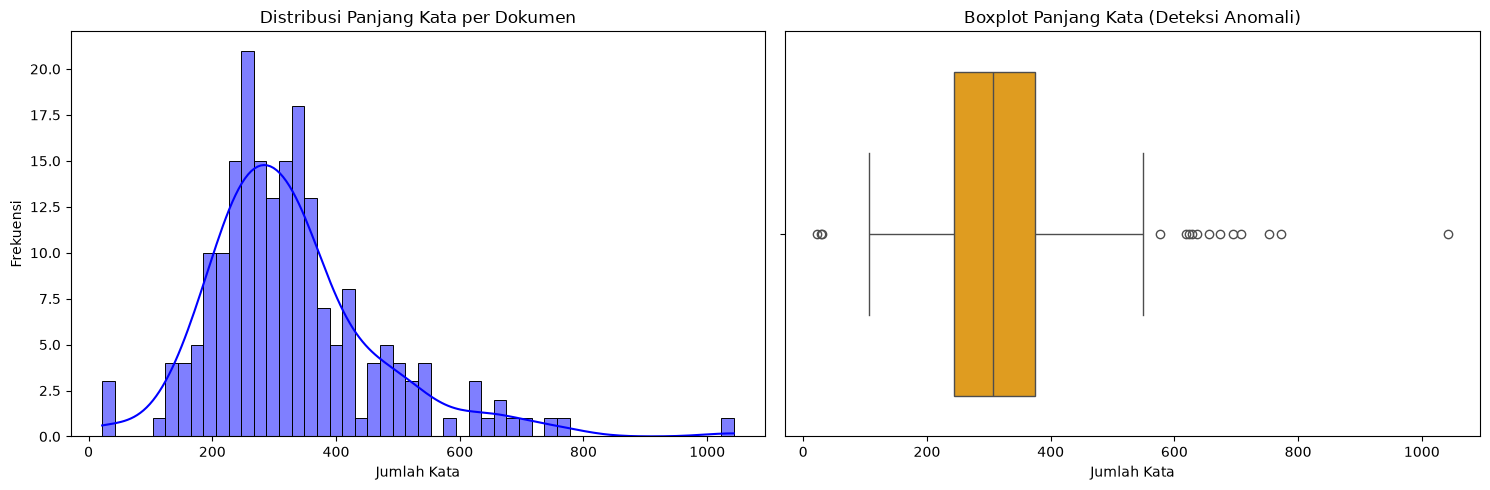

=== Statistik Deskriptif Panjang Kata ===


count     200.000000
mean      327.575000
std       138.785378
min        22.000000
25%       244.000000
50%       306.000000
75%       374.000000
max      1043.000000
Name: jumlah_kata, dtype: float64

In [ ]:
print("Menganalisis panjang kata untuk mendeteksi anomali...")
visualisasi_panjang_kata(df_all, 'isi_berita_original')

In [48]:
def visualisasi_wordcloud(series):
    teks = " ".join(series.astype(str).dropna())
    wc = WordCloud(width=1200, height=600, background_color="white").generate(teks)

    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

Membuat WordCloud...


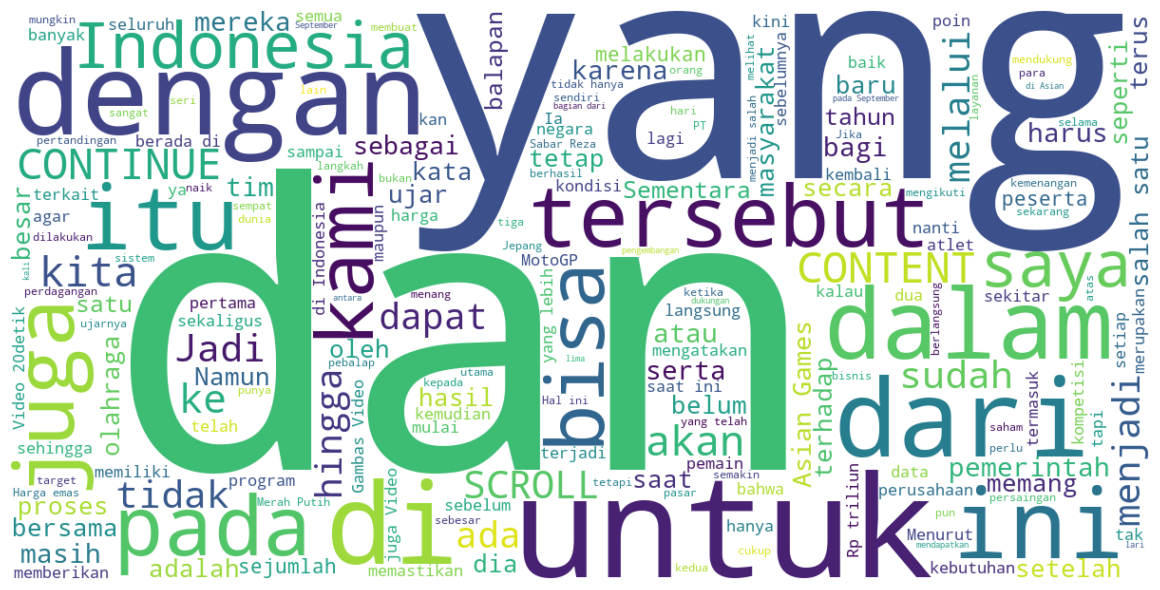

In [49]:
print("Membuat WordCloud...")
visualisasi_wordcloud(df_all['isi_berita_original'])

In [56]:
def cari_kata(keyword, nama_kolom='teks'):
    hasil_pencarian = df_all[df_all[nama_kolom].astype(str)
        .str.contains(keyword, case=False, na=False)]
    
    print(f"Ditemukan {len(hasil_pencarian)} dokumen yang mengandung kata '{keyword}'.")
    
    return hasil_pencarian[['kategori_berita', nama_kolom]]

In [57]:
hasil = cari_kata("saham", nama_kolom="isi_berita_original")
display(hasil.head())

Ditemukan 12 dokumen yang mengandung kata 'saham'.


,kategori_berita,isi_berita_original
104,finance,Indeks Harga Saham Gabungan (IHSG) dibuka meng...
106,finance,Indeks Harga Saham Gabungan (IHSG) kembali ber...
124,finance,Head of Investor Relation PT Bank Negara Indon...
134,finance,PT Adhi Karya (Persero) Tbk (ADHI) buka suara ...
140,finance,Badan Pengelola Investasi (BPI) Danantara meny...


## **Eksplorasi Teks dan Interpretasi Output**

Pada tahap pemeriksaan awal, `str.len()` digunakan untuk mengetahui panjang teks berdasarkan jumlah karakter, termasuk spasi dan tanda baca. Sementara itu, fungsi `visualisasi_panjang_kata` menghitung jumlah token menggunakan `split()`, kemudian menyajikan hasilnya dalam bentuk histogram, boxplot, dan statistik deskriptif. Kedua metode tersebut memiliki fokus pengukuran yang berbeda, sehingga hasilnya tidak dapat dianggap sebagai ukuran yang sama.

WordCloud digunakan untuk memberikan gambaran mengenai kata-kata yang paling sering muncul pada keseluruhan teks. Semakin besar ukuran suatu kata, semakin tinggi frekuensi kemunculannya. Namun, ukuran tersebut tidak menunjukkan bahwa kata tersebut memiliki tingkat kepentingan, relevansi, ataupun sentimen tertentu. Selain itu, fungsi `cari_kata` digunakan untuk menemukan kemunculan substring tanpa membedakan huruf besar dan kecil, kemudian menampilkan kategori serta cuplikan teks yang mengandung kata tersebut. Eksplorasi ini memberikan gambaran awal mengenai karakteristik korpus dan dapat menjadi dasar dalam menentukan tahapan preprocessing. Meskipun demikian, eksplorasi teks tidak menggantikan proses evaluasi model.

## **Praproses Data**

Sebelum digunakan dalam proses pembelajaran Word2Vec, teks mentah perlu diubah menjadi bentuk token. Tahapan preprocessing yang dilakukan secara konsisten penting karena Word2Vec memperlakukan setiap bentuk token sebagai unit kata yang berbeda. Oleh karena itu, perbedaan seperti penggunaan huruf kapital, tanda baca, atau variasi penulisan dapat menghasilkan kosakata tambahan yang sebenarnya tidak diperlukan dalam proses pembelajaran.

Fungsi-fungsi modular yang digunakan pada tahap ini menyediakan beberapa opsi preprocessing, seperti menghapus angka, menghilangkan stopword, dan melakukan stemming. Hasil akhir dari proses tersebut berupa **list token untuk setiap dokumen**, sesuai dengan format input yang digunakan oleh Gensim dalam pelatihan Word2Vec. Pada Skenario 1 dan Skenario 2, alur preprocessing yang digunakan tetap sama, dengan satu perbedaan utama, yaitu **keputusan untuk mempertahankan atau menghapus angka dari teks**.


In [9]:
def preprocess_modular(teks, hapus_angka=True, hapus_stopword=True, pakai_stemming=True):
    # 1. Case Folding & Hapus Tanda Baca
    teks = str(teks).lower()
    teks = re.sub(r'[^\w\s]', ' ', teks)
    
    # 2. Opsional: Hapus Angka
    if hapus_angka:
        teks = re.sub(r'\d+', '', teks)
        
    # 3. Tokenisasi
    tokens = teks.split()
    
    # 4. Opsional: Hapus Stopword
    if hapus_stopword:
        tokens = [w for w in tokens if w not in daftar_stopword]
        
    # 5. Opsional: Stemming
    if pakai_stemming:
        teks_gabung = " ".join(tokens)
        teks_stem = stemmer.stem(teks_gabung)
        tokens = teks_stem.split()
        
    # Return list of tokens (Format ideal untuk Gensim Word2Vec)
    return tokens

In [12]:
def latih_skipgram(list_of_tokens, ukuran_vektor=50, ukuran_window=2):
    """Melatih model Word2Vec Skip-gram dari kolom token dataframe."""
    model = Word2Vec(
        sentences=list_of_tokens,
        vector_size=ukuran_vektor,
        window=ukuran_window,
        sg=1,          # sg=1 mengaktifkan Skip-gram
        min_count=1,   # Pastikan semua kata masuk vocabulary
        workers=4,     # Mempercepat komputasi
        seed=42
    )
    return model

def get_vektor_rata_rata(tokens, model):
    """Merata-ratakan vektor setiap kata menjadi 1 vektor dokumen untuk klasifikasi ML."""
    vektor_kata = [model.wv[kata] for kata in tokens if kata in model.wv]
    
    if not vektor_kata:
        # Jika dokumen kosong (semua kata terhapus stopword), kembalikan array 0
        return np.zeros(model.vector_size)
        
    return np.mean(vektor_kata, axis=0)

## **Melatih Embedding dan Membentuk Fitur Dokumen**

Fungsi `latih_skipgram` digunakan untuk melatih model Word2Vec menggunakan kumpulan list token yang telah diperoleh dari tahap preprocessing. Dalam penerapannya, `ukuran_vektor=50` menunjukkan bahwa setiap kata direpresentasikan dalam bentuk vektor yang memiliki 50 komponen numerik. Parameter `ukuran_window=3` menentukan bahwa kata-kata dalam jarak maksimal tiga posisi dari kata target akan digunakan sebagai konteks. Sementara itu, `sg=1` menetapkan arsitektur yang digunakan adalah **Skip-gram**. Parameter `min_count=1` memungkinkan seluruh kata tetap masuk ke dalam kosakata meskipun hanya muncul satu kali. Pengaturan ini mencegah kata terhapus dari vocabulary, tetapi pada korpus yang relatif kecil dapat menyebabkan banyak kata langka memiliki representasi yang belum terbentuk secara optimal.

Model Word2Vec menghasilkan representasi dalam bentuk **vektor kata**, sedangkan Gaussian Naive Bayes memerlukan masukan berupa fitur dengan ukuran yang tetap untuk setiap **dokumen**. Oleh karena itu, digunakan fungsi `get_vektor_rata_rata` untuk mengubah sekumpulan vektor kata dalam sebuah dokumen menjadi satu vektor dokumen. Fungsi tersebut mengambil seluruh token yang dikenali oleh model, kemudian menghitung nilai rata-rata dari vektor-vektor tersebut.

Pada proses tersebut, `m` menunjukkan jumlah token dalam dokumen yang memiliki representasi vektor di dalam model. Meskipun jumlah kata setiap artikel berbeda-beda, hasil rata-rata tetap menghasilkan vektor dengan **50 dimensi**, sesuai dengan nilai `ukuran_vektor`. Apabila tidak terdapat satu pun token yang dikenali oleh model, fungsi akan menghasilkan vektor yang seluruh nilainya bernilai nol.

Pendekatan rata-rata vektor ini merupakan bentuk **pooling** yang sederhana dan dapat digunakan untuk menghasilkan fitur berukuran tetap dalam proses klasifikasi. Namun, metode tersebut memiliki keterbatasan karena informasi mengenai urutan kata dalam dokumen menjadi hilang. Selain itu, setiap kata yang berhasil direpresentasikan pada dasarnya berkontribusi melalui nilai rata-rata, sehingga tidak secara langsung memberikan bobot berbeda berdasarkan posisi maupun tingkat kepentingan kata dalam dokumen.


In [8]:
daftar_stopword = set(StopWordRemoverFactory().get_stop_words())
stemmer = StemmerFactory().create_stemmer()

tqdm.pandas()

## **Skenario 1: Menghapus Angka**

Daftar stopword disimpan dalam bentuk `set` agar proses pengecekan token dapat dilakukan dengan lebih efisien. Sementara itu, stemmer dari Sastrawi diinisialisasi satu kali sehingga dapat digunakan secara berulang selama proses preprocessing. Penggunaan `tqdm.pandas()` memungkinkan proses pengolahan pada kolom ditampilkan dalam bentuk bilah kemajuan, sehingga perkembangan proses dapat dipantau.

Pada Skenario 1, preprocessing dilakukan dengan konfigurasi `hapus_angka=True`, `hapus_stopword=True`, dan `pakai_stemming=True`. Artinya, angka akan dihilangkan, stopword akan disaring, dan kata berimbuhan akan diproses melalui stemming sesuai dengan pengaturan yang telah ditentukan. Pendekatan ini dapat digunakan ketika keberadaan angka dianggap kurang memberikan kontribusi dalam membedakan kategori dokumen. Namun, penghapusan angka juga berpotensi menghilangkan informasi yang bermakna, misalnya tahun, skor pertandingan, nomor pertandingan, atau nilai tertentu yang dapat memiliki hubungan dengan isi dokumen.


In [63]:
# Preprocessing Penuh (Hapus Angka, Stopword, Stemming)
print("1. Memulai Preprocessing Skenario 1 (Ini akan memakan waktu karena Stemming)...")
df_all['token_skenario_1'] = df_all['isi_berita_original'].progress_apply(
    lambda x: preprocess_modular(x, hapus_angka=True, hapus_stopword=True, pakai_stemming=True)
)

1. Memulai Preprocessing Skenario 1 (Ini akan memakan waktu karena Stemming)...


100%|██████████| 200/200 [16:25<00:00,  4.93s/it] 


In [65]:
print("\n2. Melatih Model Skip-gram...")
# Gensim memiliki sistem log tersendiri untuk menampilkan progress pelatihan
# Kita aktifkan logger-nya sejenak ke level INFO
logging.basicConfig(format='%(asctime)s : %(message)s', level=logging.INFO)

model_skenario_1 = latih_skipgram(df_all['token_skenario_1'], ukuran_vektor=50, ukuran_window=3)

# Kembalikan logger ke WARNING agar output tidak kotor setelah selesai
logging.getLogger().setLevel(logging.WARNING)
print("Pelatihan Skip-gram Selesai!")


print("\n3. Membuat Vektor Rata-rata Dokumen (Mean Pooling)...")
fitur_X = df_all['token_skenario_1'].progress_apply(
    lambda x: get_vektor_rata_rata(x, model_skenario_1)
)

# Konversi ke DataFrame
df_skenario_1_X = pd.DataFrame(fitur_X.tolist())
df_skenario_1_y = df_all['kategori_berita']

print("\nSeluruh proses Skenario 1 selesai!")


2. Melatih Model Skip-gram...
Pelatihan Skip-gram Selesai!

3. Membuat Vektor Rata-rata Dokumen (Mean Pooling)...


100%|██████████| 200/200 [00:00<00:00, 863.32it/s]


Seluruh proses Skenario 1 selesai!


In [10]:
# Skenario 2: Pertahankan Angka, Hapus Stopword, Stemming
print("2. Memulai Preprocessing Skenario 2...")
df_all['token_skenario_2'] = df_all['isi_berita_original'].progress_apply(
    lambda x: preprocess_modular(x, hapus_angka=False, hapus_stopword=True, pakai_stemming=True)
)

2. Memulai Preprocessing Skenario 2...


100%|██████████| 200/200 [18:11<00:00,  5.46s/it]


In [13]:
print("\n2. Melatih Model Skip-gram...")
# Gensim memiliki sistem log tersendiri untuk menampilkan progress pelatihan
# Kita aktifkan logger-nya sejenak ke level INFO
logging.basicConfig(format='%(asctime)s : %(message)s', level=logging.INFO)

model_skenario_1 = latih_skipgram(df_all['token_skenario_2'], ukuran_vektor=50, ukuran_window=3)

# Kembalikan logger ke WARNING agar output tidak kotor setelah selesai
logging.getLogger().setLevel(logging.WARNING)
print("Pelatihan Skip-gram Selesai!")


print("\n3. Membuat Vektor Rata-rata Dokumen (Mean Pooling)...")
fitur_X = df_all['token_skenario_2'].progress_apply(
    lambda x: get_vektor_rata_rata(x, model_skenario_1)
)

# Konversi ke DataFrame
df_skenario_2_X = pd.DataFrame(fitur_X.tolist())
df_skenario_2_y = df_all['kategori_berita']

print("\nSeluruh proses Skenario 2 selesai!")

2026-10-01 11:25:50,364 : collecting all words and their counts
2026-10-01 11:25:50,367 : PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
2026-10-01 11:25:50,399 : collected 5441 word types from a corpus of 51707 raw words and 200 sentences
2026-10-01 11:25:50,399 : Creating a fresh vocabulary
2026-10-01 11:25:50,445 : Word2Vec lifecycle event {'msg': 'effective_min_count=1 retains 5441 unique words (100.00% of original 5441, drops 0)', 'datetime': '2026-10-01T11:25:50.445101', 'gensim': '4.4.0', 'python': '3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.22621-SP0', 'event': 'prepare_vocab'}
2026-10-01 11:25:50,445 : Word2Vec lifecycle event {'msg': 'effective_min_count=1 leaves 51707 word corpus (100.00% of original 51707, drops 0)', 'datetime': '2026-10-01T11:25:50.445101', 'gensim': '4.4.0', 'python': '3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]', 'platform': 'Windo


2. Melatih Model Skip-gram...


2026-10-01 11:25:50,652 : estimated required memory for 5441 words and 50 dimensions: 4896900 bytes
2026-10-01 11:25:50,666 : resetting layer weights
2026-10-01 11:25:50,667 : Word2Vec lifecycle event {'update': False, 'trim_rule': 'None', 'datetime': '2026-10-01T11:25:50.667805', 'gensim': '4.4.0', 'python': '3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.22621-SP0', 'event': 'build_vocab'}
2026-10-01 11:25:50,667 : Word2Vec lifecycle event {'msg': 'training model with 4 workers on 5441 vocabulary and 50 features, using sg=1 hs=0 sample=0.001 negative=5 window=3 shrink_windows=True', 'datetime': '2026-10-01T11:25:50.667805', 'gensim': '4.4.0', 'python': '3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.22621-SP0', 'event': 'train'}
2026-10-01 11:25:50,903 : EPOCH 0: training on 51707 raw words (49458 effective words) took 0.2s, 217808 effective words/s
2026-1

Pelatihan Skip-gram Selesai!

3. Membuat Vektor Rata-rata Dokumen (Mean Pooling)...


100%|██████████| 200/200 [00:00<00:00, 692.12it/s]


Seluruh proses Skenario 2 selesai!


## **Skenario 2: Mempertahankan Angka**

Pada Skenario 2, konfigurasi `hapus_angka=False` digunakan sehingga angka tetap dipertahankan dalam teks. Sementara itu, proses penghapusan stopword dan stemming tetap diaktifkan. Perbandingan dengan Skenario 1 digunakan untuk mengamati apakah keberadaan informasi numerik memberikan perbedaan terhadap hasil klasifikasi berita. Agar perbandingan dapat dilakukan secara adil, kedua skenario perlu menggunakan data, pembagian data latih dan data uji, serta konfigurasi model yang sebanding. Dengan demikian, perbedaan hasil evaluasi dapat lebih tepat dikaitkan dengan perbedaan pada tahap preprocessing.

Perlu diperhatikan bahwa pada blok kode ini nama variabel model yang bersifat umum digunakan kembali, meskipun fitur untuk Skenario 2 dibentuk berdasarkan `token_skenario_2`. Selain itu, beberapa nama objek atau pesan yang masih mengacu pada Skenario 1 dapat menimbulkan kebingungan ketika membaca output. Oleh karena itu, interpretasi hasil pada bagian ini dibedakan berdasarkan sumber fitur yang digunakan, yaitu fitur yang berasal dari `token_skenario_2`.

## **Pemodelan dan Evaluasi**

Fitur dokumen yang diperoleh dari Word2Vec selanjutnya digunakan sebagai input untuk melatih model **Gaussian Naive Bayes** dalam melakukan prediksi terhadap kategori atau label dokumen. Pada proses pembagian data, parameter `test_size=0.2` digunakan untuk menempatkan 20% dokumen sebagai data pengujian, sedangkan 80% sisanya digunakan sebagai data pelatihan. Parameter `random_state=42` digunakan agar proses pembagian data menghasilkan susunan yang konsisten ketika kode dijalankan kembali. Sementara itu, `stratify` digunakan untuk mempertahankan proporsi masing-masing kelas pada data latih dan data uji.

**Catatan evaluasi:** pada alur notebook saat ini, model Word2Vec dilatih menggunakan keseluruhan dokumen sebelum proses `train_test_split`. Walaupun proses pembelajaran embedding tidak menggunakan label kategori, teks yang kemudian menjadi bagian dari data uji tetap ikut berkontribusi dalam pembentukan vocabulary dan vektor Word2Vec. Kondisi tersebut membuat evaluasi belum sepenuhnya independen karena informasi dari data uji telah ikut masuk pada tahap pembentukan fitur.

Untuk memperoleh evaluasi yang lebih ketat, pembagian data sebaiknya dilakukan terlebih dahulu. Setelah itu, model Word2Vec hanya dilatih menggunakan teks pada data latih, kemudian vektor dokumen pada data latih dan data uji dibentuk berdasarkan embedding yang diperoleh dari data latih. Pendekatan tersebut merupakan rekomendasi metodologis untuk mengurangi kemungkinan kebocoran informasi (*data leakage*). Namun, pada pembahasan ini kode notebook yang telah digunakan tetap dipertahankan.

### Skenario 1: Menghapus Angka

Pada skenario ini, model menggunakan fitur dokumen yang dihasilkan dari preprocessing Skenario 1. Tahap preprocessing tersebut menghilangkan angka, menghapus stopword, dan melakukan stemming terhadap kata sebelum digunakan dalam pembentukan embedding Word2Vec.

**Pembagian Data Skenario 1.** Fitur dokumen yang disimpan pada `X` dan label pada `y` dibagi menggunakan urutan pembagian yang sama. Parameter `stratify` digunakan untuk mempertahankan komposisi setiap kelas pada data pelatihan dan pengujian. Selanjutnya, hasil prediksi terhadap data uji digunakan untuk mengukur kemampuan classifier dalam mengategorikan dokumen yang tidak digunakan secara langsung dalam proses pelatihan Gaussian Naive Bayes.


In [70]:
X_train, X_test, y_train, y_test = train_test_split(
    df_skenario_1_X, df_skenario_1_y, 
    test_size=0.2, 
    random_state=42, 
    stratify=df_skenario_1_y
)

**Gaussian Naive Bayes Skenario 1.** Proses `fit` digunakan untuk mempelajari pola hubungan antara 50 fitur hasil representasi embedding dengan kategori label berdasarkan data latih. Setelah proses pembelajaran selesai, `predict` digunakan untuk menghasilkan prediksi kategori pada data uji. Gaussian Naive Bayes memodelkan distribusi nilai setiap fitur pada masing-masing kelas dengan asumsi bahwa fitur-fitur tersebut bersifat independen ketika kelas telah diketahui. Asumsi tersebut merupakan bagian dari pendekatan pemodelan yang digunakan, sehingga kualitas model tetap perlu diketahui melalui hasil evaluasi pada data uji.


In [71]:
model_nb_skenario1 = GaussianNB()

# 3. Melatih Model dengan Data Latih
model_nb_skenario1.fit(X_train, y_train)

# 4. Memprediksi Data Uji
y_pred = model_nb_skenario1.predict(X_test)

**Membaca Evaluasi Skenario 1.** Accuracy menunjukkan persentase keseluruhan prediksi yang berhasil diklasifikasikan dengan benar. Precision menunjukkan ketepatan model ketika memberikan prediksi untuk suatu kelas, sedangkan recall menunjukkan kemampuan model dalam menemukan anggota yang sebenarnya termasuk dalam kelas tersebut. F1-score merupakan nilai gabungan yang menggambarkan keseimbangan antara precision dan recall. Nilai-nilai tersebut pada classification report ditampilkan untuk masing-masing kategori.

Pada confusion matrix, **baris menunjukkan label sebenarnya**, sedangkan **kolom menunjukkan label hasil prediksi**. Nilai yang berada pada diagonal menunjukkan jumlah prediksi yang benar, sementara nilai di luar diagonal menunjukkan dokumen yang mengalami kesalahan klasifikasi. Kesimpulan mengenai kelas yang lebih mudah atau lebih sulit dikenali sebaiknya didasarkan pada angka evaluasi aktual yang dihasilkan oleh notebook, bukan berdasarkan asumsi sebelum melihat hasilnya.


=== HASIL EVALUASI NAIVE BAYES (SKENARIO 1) ===
Akurasi Model : 95.00%

Laporan Klasifikasi Detail:
              precision    recall  f1-score   support

     finance       1.00      0.90      0.95        20
       sport       0.91      1.00      0.95        20

    accuracy                           0.95        40
   macro avg       0.95      0.95      0.95        40
weighted avg       0.95      0.95      0.95        40



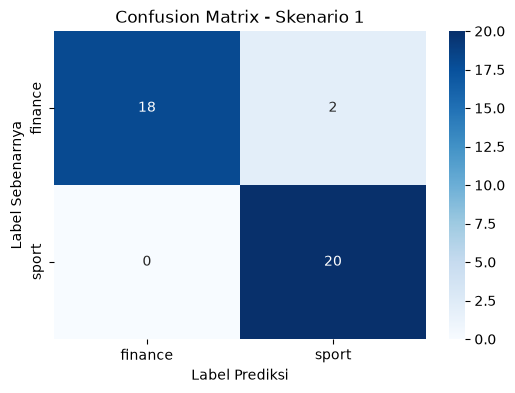

In [72]:
print("=== HASIL EVALUASI NAIVE BAYES (SKENARIO 1) ===")
print(f"Akurasi Model : {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("Laporan Klasifikasi Detail:")
print(classification_report(y_test, y_pred))

# 6. Visualisasi Confusion Matrix (Opsional, sangat bagus untuk laporan)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=model_nb_skenario1.classes_, 
            yticklabels=model_nb_skenario1.classes_)
plt.title('Confusion Matrix - Skenario 1')
plt.ylabel('Label Sebenarnya')
plt.xlabel('Label Prediksi')
plt.show()

## **Skenario 2: Angka Dipertahankan**

Pada skenario ini, fitur dokumen diperoleh dari preprocessing yang mempertahankan angka dalam teks. Sementara itu, tahapan lainnya tetap dilakukan dengan menghapus stopword dan menerapkan stemming. Hasil evaluasi kemudian dibandingkan dengan Skenario 1 menggunakan metrik yang sama agar perbedaan performa dapat diamati secara konsisten. Keberadaan angka tidak dapat secara langsung dianggap selalu memberikan dampak positif maupun negatif, karena pengaruhnya bergantung pada sejauh mana informasi numerik dalam artikel dapat membantu membedakan kategori dokumen.

**Pembagian Data Skenario 2.** Proses pembagian data menggunakan parameter yang sama seperti pada Skenario 1 untuk menjaga kesetaraan dalam perbandingan. Parameter `stratify=df_skenario_2_y` digunakan untuk mempertahankan proporsi setiap kategori ketika dokumen dibagi menjadi data latih dan data uji. Dengan demikian, kedua bagian data tetap memiliki distribusi kelas yang sebanding dengan data sebelum pembagian.


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    df_skenario_2_X, df_skenario_2_y, 
    test_size=0.2, 
    random_state=42, 
    stratify=df_skenario_2_y
)

**Gaussian Naive Bayes Skenario 2.** Classifier pada skenario ini dilatih menggunakan fitur `df_skenario_2_X` beserta label kategori dari Skenario 2. Tahap `fit` digunakan untuk mempelajari pola berdasarkan data latih, kemudian `predict` digunakan untuk menghasilkan prediksi terhadap data uji. Sama seperti pada Skenario 1, Gaussian Naive Bayes memodelkan setiap fitur dengan asumsi distribusi Gaussian pada masing-masing kelas serta menganggap fitur-fitur tersebut memiliki independensi bersyarat ketika kelas telah diketahui.


In [15]:
model_nb_skenario1 = GaussianNB()

# 3. Melatih Model dengan Data Latih
model_nb_skenario1.fit(X_train, y_train)

# 4. Memprediksi Data Uji
y_pred = model_nb_skenario1.predict(X_test)

**Membaca Evaluasi Skenario 2.** Hasil evaluasi perlu dibaca secara menyeluruh dengan memperhatikan accuracy, precision, recall, F1-score, serta confusion matrix. Hasil tersebut kemudian dapat dibandingkan dengan Skenario 1 berdasarkan label dan pembagian data yang sebanding. Perbedaan nilai pada setiap metrik menunjukkan perubahan performa yang terjadi dalam eksperimen ini. Namun, karena jumlah data yang digunakan masih terbatas dan embedding Word2Vec dipelajari dari korpus yang relatif kecil, perbedaan tersebut belum cukup untuk dijadikan dasar dalam menyatakan bahwa salah satu pendekatan preprocessing secara umum lebih unggul daripada pendekatan lainnya.


=== HASIL EVALUASI NAIVE BAYES (SKENARIO 1) ===
Akurasi Model : 75.00%

Laporan Klasifikasi Detail:
              precision    recall  f1-score   support

     finance       0.73      0.80      0.76        20
       sport       0.78      0.70      0.74        20

    accuracy                           0.75        40
   macro avg       0.75      0.75      0.75        40
weighted avg       0.75      0.75      0.75        40



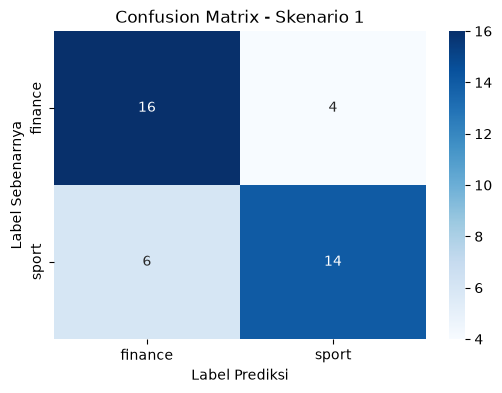

In [75]:
print("=== HASIL EVALUASI NAIVE BAYES (SKENARIO 1) ===")
print(f"Akurasi Model : {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("Laporan Klasifikasi Detail:")
print(classification_report(y_test, y_pred))

# 6. Visualisasi Confusion Matrix (Opsional, sangat bagus untuk laporan)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=model_nb_skenario1.classes_, 
            yticklabels=model_nb_skenario1.classes_)
plt.title('Confusion Matrix - Skenario 1')
plt.ylabel('Label Sebenarnya')
plt.xlabel('Label Prediksi')
plt.show()

## **Kesimpulan**

Secara keseluruhan, alur penerapan pada notebook dimulai dari artikel hasil scraping yang melalui proses preprocessing hingga menjadi token. Token tersebut kemudian digunakan untuk melatih embedding kata menggunakan arsitektur **Skip-gram**. Vektor kata yang dihasilkan selanjutnya dirata-ratakan untuk membentuk satu representasi vektor pada setiap dokumen, kemudian digunakan sebagai fitur bagi **Gaussian Naive Bayes** dalam melakukan klasifikasi kategori berita. Sebagai pembanding, **CBOW** memiliki arah pembelajaran yang berbeda, yaitu menggunakan kumpulan kata konteks untuk memprediksi kata target, sedangkan Skip-gram menggunakan kata target untuk memprediksi kata-kata yang berada di sekitarnya.

Hasil evaluasi perlu dipahami berdasarkan batasan dari eksperimen yang dilakukan. Dataset yang digunakan memiliki jumlah artikel yang relatif terbatas jika dibandingkan dengan korpus berukuran besar yang umumnya diperlukan untuk menghasilkan embedding kata yang lebih stabil. Penggunaan `min_count=1` juga membuat kata yang hanya muncul sedikit atau satu kali tetap dimasukkan ke dalam kosakata, meskipun jumlah konteks yang tersedia untuk mempelajari representasinya terbatas. Selain itu, proses **average pooling** pada vektor kata menghilangkan informasi mengenai urutan kata dalam dokumen karena seluruh token dirangkum melalui nilai rata-rata.

Dari sisi metodologi, evaluasi yang lebih ketat dapat dilakukan dengan membagi dokumen menjadi data latih dan data uji **sebelum** proses pelatihan Word2Vec. Model embedding kemudian dilatih hanya menggunakan dokumen pada data latih, sedangkan dokumen uji direpresentasikan menggunakan embedding yang telah diperoleh dari data latih. Token pada data uji yang tidak terdapat dalam kosakata juga perlu ditangani secara eksplisit. Pendekatan tersebut dapat mengurangi kemungkinan informasi dari data uji ikut memengaruhi proses pembentukan embedding. Perubahan ini merupakan rekomendasi metodologis dan tidak diterapkan pada kode notebook yang digunakan.

Dalam penyusunan kesimpulan akhir, nilai **accuracy, precision, recall, F1-score**, dan hasil **confusion matrix** sebaiknya diambil langsung dari keluaran aktual notebook. Apabila metrik menunjukkan adanya perbedaan performa antara Skenario 1 dan Skenario 2, perbedaan tersebut dapat dijelaskan sebagai hasil dari eksperimen pada dataset yang digunakan. Namun, hasil tersebut tetap perlu disertai keterbatasan penelitian dan tidak dapat secara langsung digeneralisasikan sebagai gambaran kinerja Word2Vec secara umum.


In [1]:
print("=== Vektor Kata Hasil Skip-gram ===")
model_vektor = globals().get("model_skenario_1", globals().get("model_skipgram"))

if model_vektor is None:
    print("Jalankan sel pelatihan Skip-gram terlebih dahulu.")
elif model_vektor.wv.index_to_key:
    kata_uji_hasil = next(
        (kata for kata in ("saham", "bank", "pasar") if kata in model_vektor.wv),
        model_vektor.wv.index_to_key[0],
    )
    vektor_kata_hasil = model_vektor.wv[kata_uji_hasil]
    print(f"Kata: {kata_uji_hasil}")
    print(f"Dimensi: {vektor_kata_hasil.shape[0]}")
    print(f"Vektor kata: {np.round(vektor_kata_hasil, 4)}")
else:
    print("Vocabulary model kosong; tidak ada vektor kata untuk ditampilkan.")

vektor_dokumen_df = globals().get("df_skenario_2_X", globals().get("df_skenario_1_X"))
if vektor_dokumen_df is not None:
    print(f"\nBentuk matriks vektor dokumen: {vektor_dokumen_df.shape}")
    if not vektor_dokumen_df.empty:
        print(f"Vektor dokumen pertama: {np.round(vektor_dokumen_df.iloc[0].to_numpy(), 4)}")

=== Vektor Kata Hasil Skip-gram ===
Jalankan sel pelatihan Skip-gram terlebih dahulu.


In [16]:
from pathlib import Path
import joblib

model_skipgram_simpan = globals().get("model_skenario_1")
model_nb_simpan = globals().get("model_nb_skenario1")

if model_skipgram_simpan is None or model_nb_simpan is None:
    print("Jalankan sel pelatihan Skip-gram dan Gaussian Naive Bayes terlebih dahulu.")
else:
    path_skipgram = Path("model_skipgram_skenario2.model")
    path_naive_bayes = Path("model_skipgram_naive_bayes_skenario2.joblib")

    model_skipgram_simpan.save(str(path_skipgram))
    joblib.dump(model_nb_simpan, path_naive_bayes)

    print(f"Model Skip-gram tersimpan: {path_skipgram.resolve()}")
    print(f"Model Skip-gram + Naive Bayes tersimpan: {path_naive_bayes.resolve()}")

Model Skip-gram tersimpan: C:\Users\LENOVO\Downloads\PPW\PPW\tugas\model_skipgram_skenario2.model
Model Skip-gram + Naive Bayes tersimpan: C:\Users\LENOVO\Downloads\PPW\PPW\tugas\model_skipgram_naive_bayes_skenario2.joblib


## **Demo Aplikasi Klasifikasi Berita Berbasis Streamlit**

Selain eksperimen dan evaluasi model pada notebook ini, model Skip-gram dan Gaussian Naive Bayes juga digunakan dalam aplikasi demo berbasis **Streamlit**. Aplikasi ini memungkinkan pengguna mencoba klasifikasi artikel Detik.com melalui antarmuka web tanpa menjalankan ulang proses pelatihan model.

### Tujuan dan kategori klasifikasi

Demo ini menunjukkan penerapan model yang telah disimpan untuk mengelompokkan artikel ke dalam salah satu dari dua kategori, yaitu **Sport** dan **Finance**. Aplikasi memuat model Skip-gram dan Gaussian Naive Bayes dari berkas yang telah disiapkan. Proses untuk setiap artikel merupakan inferensi atau prediksi, bukan pelatihan ulang model.

### Cara menggunakan aplikasi

1. Buka aplikasi Streamlit yang telah di-deploy, atau jalankan aplikasi secara lokal dari direktori utama proyek 
2. Masukkan URL artikel lengkap dengan protokol `https://` dari domain `detik.com` atau subdomain resminya, misalnya `sport.detik.com` atau `finance.detik.com`.
3. Pilih tombol **Analisis berita** dan tunggu hingga pengambilan artikel serta klasifikasi selesai.
4. Amati kategori prediksi dan tingkat keyakinan. Buka bagian **Jelajahi teks yang dianalisis** untuk memeriksa isi artikel dan token hasil preprocessing.

> **Tautan deployment:** tambahkan URL Streamlit Community Cloud di bagian ini setelah aplikasi berhasil di-deploy. Pastikan tautan dapat dibuka saat demo akan digunakan atau dipresentasikan; ketersediaannya bergantung pada status deployment dan koneksi internet.

### Alur pemrosesan

Aplikasi mengambil judul dan isi artikel dari halaman berita. Teks kemudian diubah menjadi huruf kecil, tanda baca dibersihkan, stopword bahasa Indonesia dihapus, lalu kata dinormalisasi menggunakan stemming Sastrawi. Angka dipertahankan, sesuai konfigurasi preprocessing skenario 2.

Token hasil preprocessing dicocokkan dengan kosakata Skip-gram. Vektor kata yang tersedia dirata-ratakan (*mean pooling*) untuk membentuk satu vektor dokumen. Vektor ini diberikan kepada Gaussian Naive Bayes untuk menghasilkan prediksi **Sport** atau **Finance**. Aplikasi menampilkan kategori prediksi, tingkat keyakinan, probabilitas kedua kategori, serta teks dan token yang diproses.

### Batasan demo

Demo ini merupakan sarana untuk mencoba penerapan model pada artikel baru, bukan pengganti evaluasi ilmiah pada data uji. Kategori yang tersedia terbatas pada **Sport** dan **Finance**, sehingga artikel di luar kedua topik tersebut tetap akan dipaksa masuk ke salah satu kategori. Tingkat keyakinan adalah keluaran probabilitas model dan tidak menjamin klasifikasi selalu benar. Hasil juga bergantung pada isi artikel yang berhasil diambil, kecocokan token dengan kosakata Skip-gram, serta ketersediaan situs dan aplikasi saat digunakan.